In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import optuna
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

from scipy.sparse.linalg import svds
from scipy.sparse import coo_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import random

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/movies.csv
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/ratings.csv
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/README.txt
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/tags.csv
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/links.csv


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Load the DataFrame</span> 
  </h1>
</div>

In [19]:
df = pd.read_csv('/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/ratings.csv')
movies = pd.read_csv('/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/movies.csv') 

In [9]:
# Show first five rows
df.head()

,userId,movieId,rating,timestamp,user_id,movie_id
66669,429,165,4.0,828124615,428,531
66719,429,595,5.0,828124615,428,323
66713,429,434,4.0,828124615,428,633
66717,429,590,5.0,828124615,428,32
66716,429,588,5.0,828124615,428,322


In [20]:
user_ids = df['userId'].unique().tolist()
user_map = {x: i for i, x in enumerate(user_ids)}

movie_ids = df['movieId'].unique().tolist()
movie_map = {x: i for i, x in enumerate(movie_ids)}

movie_ids2 = movies['movieId'].unique().tolist()
movie_map2 = {x: i for i, x in enumerate(movie_ids2)}

df['user_id'] = df['userId'].map(user_map)
df['movie_id'] = df['movieId'].map(movie_map)
movies['movie_id'] = movies['movieId'].map(movie_map2)

In [21]:
n_users = len(user_ids)
n_items = len(movie_ids)
print(f"Users: {n_users} | Items: {n_items}")

Users: 610 | Items: 9724


In [ ]:
df.describe()

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Splitting the Data into Train and Test</span> 
  </h1>
</div>

# Time Split

In [22]:
df = df.sort_values('timestamp') # Sorting the data

sort_index = int(len(df) * 0.64)

train_df = df[:sort_index].copy()
test_df = df[sort_index:].copy()

train_df['label'] = (train_df['rating'] >= 4).astype(int)
test_df['label'] = (test_df['rating'] >= 4).astype(int)

In [23]:
class ImplicitDataset(Dataset):
    def __init__(self, df, n_items, num_neg=4):
        self.users = df['user_id'].values
        self.items = df['movie_id'].values
        self.labels = df['label'].values
        self.n_items = n_items
        self.num_neg = num_neg
        
    def __len__(self):
        return len(self.users) * (1 + self.num_neg)
    
    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.num_neg)
        u = self.users[pos_idx]
        i = self.items[pos_idx]
        
        if idx % (1 + self.num_neg) == 0:   # positive sample
            return u, i, 1
        else:                               # negative sample
            j = random.randint(0, self.n_items - 1)
            while j == i:                   # avoid sampling the same item
                j = random.randint(0, self.n_items - 1)
            return u, j, 0

In [24]:
train_dataset = ImplicitDataset(train_df, n_items, num_neg=4)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=2, pin_memory=True)

## Equation 3:
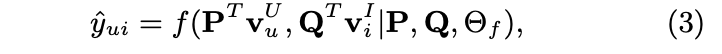

## Equation 4:
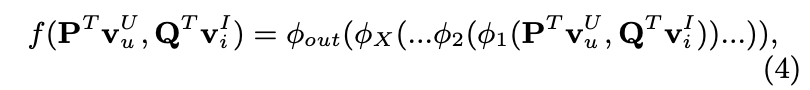

In [25]:
class NeuMF(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=8, layers=[32, 16, 8]):
        super().__init__()
        
        # Embedding tables P and Q (from Equation 3)
        self.user_embedding = nn.Embedding(n_users, embedding_dim)   # P
        self.item_embedding = nn.Embedding(n_items, embedding_dim)   # Q
        
        # Neural CF layers (the tower in Equation 4)
        self.layers = nn.ModuleList()
        input_size = embedding_dim * 2  # concatenate user + item
        
        for layer_size in layers:
            self.layers.append(nn.Linear(input_size, layer_size))
            input_size = layer_size
        
        # Output layer φ_out
        self.output_layer = nn.Linear(input_size, 1)
        
        self.dropout = nn.Dropout(0.1)
        
        self.gmf = nn.Linear(embedding_dim, 1)
        
    def forward(self, user_ids, item_ids):
        # Get embeddings: P^T v_u and Q^T v_i
        user_emb = self.user_embedding(user_ids)      # shape: (batch, embedding_dim)
        item_emb = self.item_embedding(item_ids)
        
        gmf_input = torch.mul(user_emb, item_emb)               
        gmf_output = self.gmf(gmf_input)  
        
        # Concatenate (this is the input to φ1)
        x = torch.cat([user_emb, item_emb], dim=1)
        
        # Pass through all neural CF layers φ1 → φ2 → ... → φX
        for layer in self.layers:
            x = layer(x)
            x = self.dropout(torch.relu(x))         # paper uses ReLU
        
        # Final output layer φ_out + sigmoid
        mlp_output = self.output_layer(x)
        combined_output = torch.cat([gmf_output, mlp_output], dim=1)
        
        raw_pred = torch.sum(combined_output, dim=1)
        
        return torch.sigmoid(raw_pred)      # score between 0 and 1

In [8]:
train_df.tail()

,userId,movieId,rating,timestamp,user_id,movie_id,label
67002,432,49530,2.5,1315244340,431,2319,0
66958,432,6953,3.0,1315244347,431,2243,0
66817,432,356,4.5,1315244359,431,20,1
67046,432,81788,4.0,1315244362,431,1319,1
67036,432,74458,4.5,1315244366,431,242,1


In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NeuMF(n_users, n_items, embedding_dim=32, layers=[256, 128, 64, 32, 16]).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.BCELoss()

print("Starting training...")
for epoch in range(10):   # 20 epochs is enough for MovieLens small
    model.train()
    total_loss = 0.0
    for u, i, y in train_loader:
        u, i, y = u.to(device), i.to(device), y.float().to(device)
        
        optimizer.zero_grad()
        preds = model(u, i)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1:2d} | Loss: {total_loss/len(train_loader):.4f}")

Starting training...
Epoch  1 | Loss: 0.5219
Epoch  2 | Loss: 0.4669
Epoch  3 | Loss: 0.3879
Epoch  4 | Loss: 0.3480
Epoch  5 | Loss: 0.3312
Epoch  6 | Loss: 0.3213
Epoch  7 | Loss: 0.3161
Epoch  8 | Loss: 0.3111
Epoch  9 | Loss: 0.3080
Epoch 10 | Loss: 0.3049


In [28]:
# Quick validation AUC on test set (positive + random negatives)
model.eval()
with torch.no_grad():
    test_users = torch.tensor(test_df['user_id'].values, device=device)
    test_items = torch.tensor(test_df['movie_id'].values, device=device)
    test_labels = test_df['label'].values
    test_preds = model(test_users, test_items).cpu().numpy()
    auc = roc_auc_score(test_labels, test_preds)
    print(f"Test AUC: {auc:.4f}")

Test AUC: 0.5707


In [29]:
@torch.no_grad()
def recommend_top_n(model, user_id: int, top_n: int = 10, device=torch.device('cpu')):
    model.eval()
    model.to(device)
    
    all_items = torch.arange(n_items, device=device)
    user_tensor = torch.full((n_items,), user_id, dtype=torch.long, device=device)
    
    scores = model(user_tensor, all_items).cpu().numpy()
    
    # Get top-N indices (highest predicted probability)
    top_indices = np.argsort(scores)[::-1][:top_n]
    top_scores = scores[top_indices]
    
    # Map back to original movieId + title
    recs = []
    for idx, score in zip(top_indices, top_scores):
        orig_movie_id = movie_ids[idx]                    # original movieId
        title = movies[movies['movieId'] == orig_movie_id]['title'].values[0]
        recs.append((orig_movie_id, title, float(score)))
    
    return recs

In [31]:
# Pick a random user from the dataset
random_user_mapped = random.choice(train_df['user_id'].unique())
print(f"\n=== Top 10 recommendations for random user (mapped ID {random_user_mapped}) ===")
recommendations = recommend_top_n(model, random_user_mapped, top_n=10)

for rank, (movie_id, title, score) in enumerate(recommendations, 1):
    print(f"{rank:2d}. {title:<60} | score = {score:.4f}")


=== Top 10 recommendations for random user (mapped ID 439) ===
 1. Matrix, The (1999)                                           | score = 0.9150
 2. Terminator 2: Judgment Day (1991)                            | score = 0.9105
 3. Silence of the Lambs, The (1991)                             | score = 0.9098
 4. Independence Day (a.k.a. ID4) (1996)                         | score = 0.9034
 5. Shawshank Redemption, The (1994)                             | score = 0.8972
 6. Star Wars: Episode V - The Empire Strikes Back (1980)        | score = 0.8943
 7. Jurassic Park (1993)                                         | score = 0.8924
 8. Braveheart (1995)                                            | score = 0.8914
 9. Star Wars: Episode IV - A New Hope (1977)                    | score = 0.8898
10. Pulp Fiction (1994)                                          | score = 0.8887
